# 03 — Model Training & Evaluation
Train three models, compare them, and run an ablation study.

**Run `02_preprocessing.ipynb` first** so the `data/` folder exists.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import json
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import cross_val_score

import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


os.makedirs('models',  exist_ok=True)
os.makedirs('figures', exist_ok=True)

plt.rcParams.update({
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'figure.dpi': 120,
})

## Load processed data

In [2]:
X_train       = np.load('data/X_train.npy')
X_test        = np.load('data/X_test.npy')
y_train       = np.load('data/y_train.npy')
y_test        = np.load('data/y_test.npy')
feature_names = joblib.load('data/feature_names.pkl')

# Keep DataFrames for LightGBM feature names
X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_test_df  = pd.DataFrame(X_test,  columns=feature_names)

print('X_train:', X_train.shape, '  X_test:', X_test.shape)

X_train: (71792, 28)   X_test: (17948, 28)


## Helper: compute metrics

In [3]:
def compute_metrics(y_true, y_pred, name=''):
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f'  {name:28s}  RMSE={rmse:.3f}  MAE={mae:.3f}  R²={r2:.3f}')
    return {'model': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

## 1. Linear Regression (baseline)

In [4]:
lr = LinearRegression()
lr.fit(X_train, y_train)
lr_pred = lr.predict(X_test)
lr_m = compute_metrics(y_test, lr_pred, 'Linear Regression')
joblib.dump(lr, 'models/linear_regression.pkl')

  Linear Regression             RMSE=16.966  MAE=12.109  R²=0.322


['models/linear_regression.pkl']

## 2. Random Forest

In [5]:
rf = RandomForestRegressor(
    n_estimators=200, max_depth=15,
    min_samples_leaf=4, random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_m = compute_metrics(y_test, rf_pred, 'Random Forest')
joblib.dump(rf, 'models/random_forest.pkl')

  Random Forest                 RMSE=15.475  MAE=10.783  R²=0.436


['models/random_forest.pkl']

## 3. LightGBM with Optuna tuning

In [6]:
def lgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_int('n_estimators', 200, 1200, step=100),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves':       trial.suggest_int('num_leaves', 31, 127),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_samples':trial.suggest_int('min_child_samples', 10, 50),
        'reg_alpha':        trial.suggest_float('reg_alpha', 1e-3, 1.0, log=True),
        'reg_lambda':       trial.suggest_float('reg_lambda', 1e-3, 1.0, log=True),
        'random_state': 42, 'n_jobs': -1, 'verbose': -1,
    }
    model  = lgb.LGBMRegressor(**params)
    scores = cross_val_score(
        model, X_train_df, y_train,
        cv=5, scoring='neg_root_mean_squared_error', n_jobs=-1
    )
    return -scores.mean()

study = optuna.create_study(
    direction='minimize',
    sampler=optuna.samplers.TPESampler(seed=42)
)
study.optimize(lgb_objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_params.update({'random_state': 42, 'n_jobs': -1, 'verbose': -1})
print('\nBest CV RMSE:', round(study.best_value, 4))
print('Best params: ', best_params)

with open('models/lgb_best_params.json', 'w') as f:
    json.dump(best_params, f, indent=2)

  0%|          | 0/30 [00:00<?, ?it/s]


Best CV RMSE: 15.3462
Best params:  {'n_estimators': 1100, 'learning_rate': 0.02910106747126825, 'num_leaves': 106, 'subsample': 0.6347264216551218, 'colsample_bytree': 0.8769911634874247, 'min_child_samples': 25, 'reg_alpha': 0.530632904071129, 'reg_lambda': 0.06190372295915489, 'random_state': 42, 'n_jobs': -1, 'verbose': -1}


In [7]:
lgb_model = lgb.LGBMRegressor(**best_params)
lgb_model.fit(X_train_df, y_train)
lgb_pred = lgb_model.predict(X_test_df)
lgb_m = compute_metrics(y_test, lgb_pred, 'LightGBM')
joblib.dump(lgb_model, 'models/lightgbm.pkl')

  LightGBM                      RMSE=15.371  MAE=10.692  R²=0.443


['models/lightgbm.pkl']

## 4. Results table

In [8]:
results = [lr_m, rf_m, lgb_m]
results_df = pd.DataFrame(results).set_index('model')
print(results_df.round(3).to_string())
results_df

                     RMSE     MAE     R2
model                                   
Linear Regression  16.966  12.109  0.322
Random Forest      15.475  10.783  0.436
LightGBM           15.371  10.692  0.443


,RMSE,MAE,R2
model,,,
Linear Regression,16.965653,12.108885,0.321907
Random Forest,15.474739,10.783423,0.435850
LightGBM,15.371248,10.692062,0.443370


## 6. Model comparison bar chart

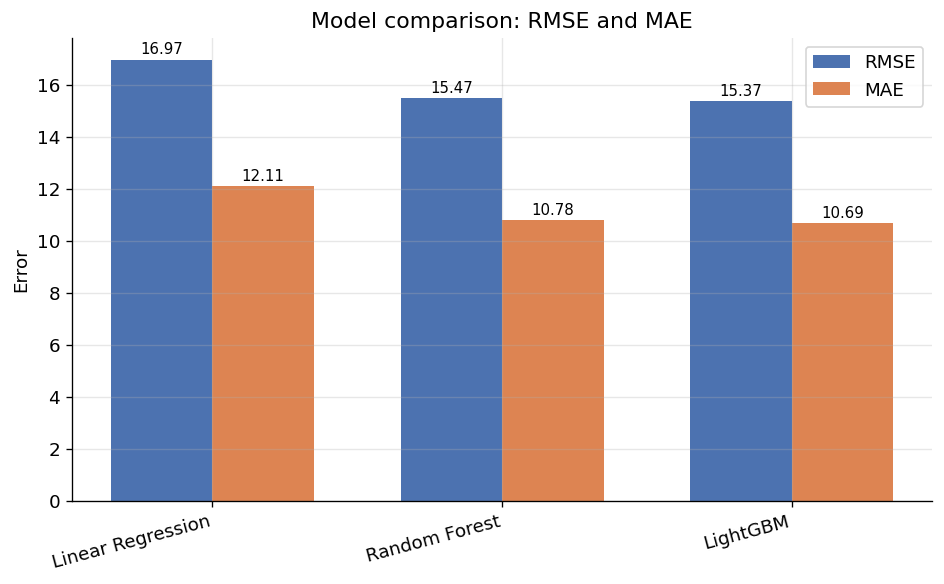

In [9]:
models  = [r['model'] for r in results]
rmse_v  = [r['RMSE']  for r in results]
mae_v   = [r['MAE']   for r in results]
x = np.arange(len(models))
w = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
b1 = ax.bar(x - w/2, rmse_v, w, label='RMSE', color='#4C72B0')
b2 = ax.bar(x + w/2, mae_v,  w, label='MAE',  color='#DD8452')
ax.set_ylabel('Error')
ax.set_title('Model comparison: RMSE and MAE')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.legend()
for bar in list(b1) + list(b2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
            f'{bar.get_height():.2f}', ha='center', va='bottom', fontsize=9)
fig.tight_layout()
fig.savefig('figures/06_model_comparison.png')
plt.show()

## 7. Predicted vs actual & residuals (LightGBM)

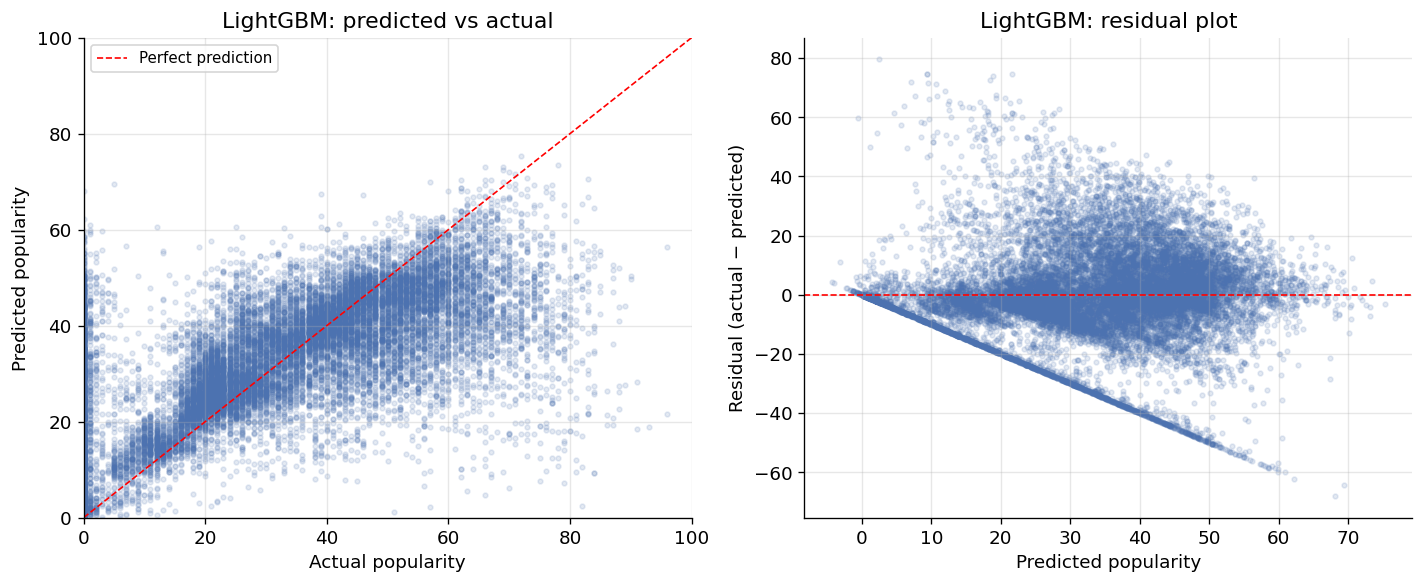

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Predicted vs actual
ax = axes[0]
ax.scatter(y_test, lgb_pred, alpha=0.15, s=8, color='#4C72B0', rasterized=True)
ax.plot([0, 100], [0, 100], 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlim(0, 100); ax.set_ylim(0, 100)
ax.set_xlabel('Actual popularity')
ax.set_ylabel('Predicted popularity')
ax.set_title('LightGBM: predicted vs actual')
ax.legend(fontsize=9)

# Residuals
ax = axes[1]
residuals = y_test - lgb_pred
ax.scatter(lgb_pred, residuals, alpha=0.15, s=8, color='#4C72B0', rasterized=True)
ax.axhline(0, color='red', linewidth=1, linestyle='--')
ax.set_xlabel('Predicted popularity')
ax.set_ylabel('Residual (actual − predicted)')
ax.set_title('LightGBM: residual plot')

fig.tight_layout()
fig.savefig('figures/07_pred_vs_actual_and_residuals.png')
plt.show()

## 8. LightGBM feature importance (gain)

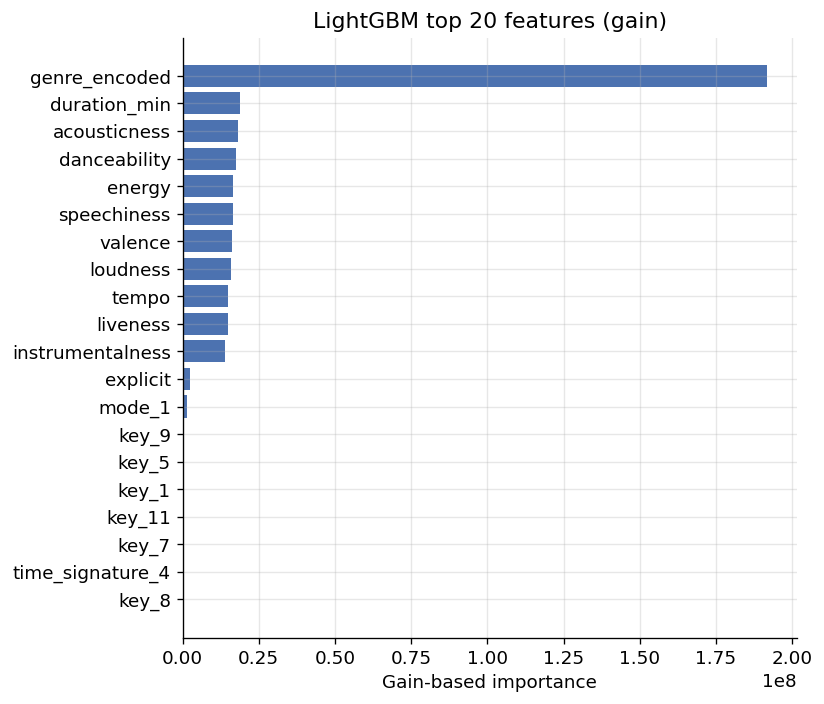

In [11]:
importance = lgb_model.booster_.feature_importance(importance_type='gain')
fi = pd.Series(importance, index=feature_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(fi.index[::-1], fi.values[::-1], color='#4C72B0')
ax.set_xlabel('Gain-based importance')
ax.set_title('LightGBM top 20 features (gain)')
fig.tight_layout()
fig.savefig('figures/09_lgb_feature_importance.png')
plt.show()

## 9. Ablation study: genre encoding

In [12]:
genre_col = 'genre_encoded'
X_tr_ng = X_train_df.drop(columns=[genre_col])
X_te_ng = X_test_df.drop(columns=[genre_col])

lgb_ng = lgb.LGBMRegressor(**best_params)
lgb_ng.fit(X_tr_ng, y_train)
pred_ng = lgb_ng.predict(X_te_ng)
ng_m = compute_metrics(y_test, pred_ng, 'LightGBM (no genre)')

print(f"\nRMSE increase from removing genre: +{(ng_m['RMSE'] - lgb_m['RMSE']):.3f} "
      f"({(ng_m['RMSE'] - lgb_m['RMSE']) / lgb_m['RMSE'] * 100:.1f}%)")

  LightGBM (no genre)           RMSE=18.172  MAE=14.256  R²=0.222

RMSE increase from removing genre: +2.800 (18.2%)


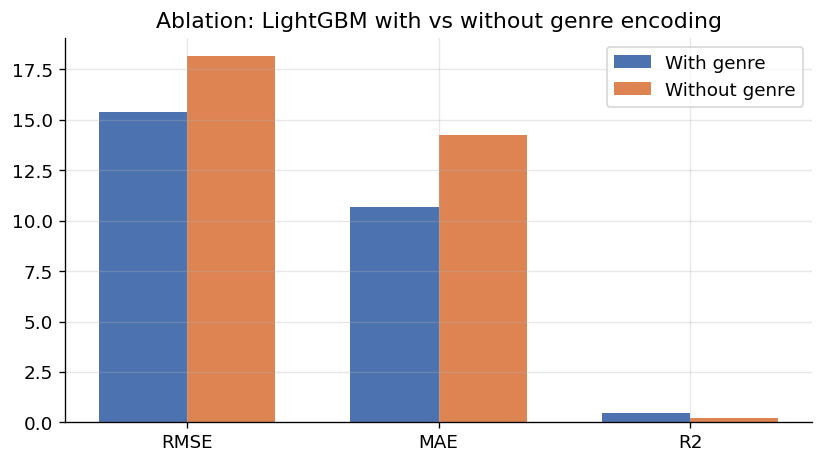

In [13]:
# Ablation bar chart
metrics_to_plot = ['RMSE', 'MAE', 'R2']
x = np.arange(len(metrics_to_plot))
w = 0.35

with_vals    = [lgb_m[m]  for m in metrics_to_plot]
without_vals = [ng_m[m]   for m in metrics_to_plot]

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(x - w/2, with_vals,    w, label='With genre',    color='#4C72B0')
ax.bar(x + w/2, without_vals, w, label='Without genre', color='#DD8452')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_plot)
ax.set_title('Ablation: LightGBM with vs without genre encoding')
ax.legend()
fig.tight_layout()
fig.savefig('figures/10_ablation_genre.png')
plt.show()